In [3]:
# ==========================================
# Customer Churn Prediction - ML Pipeline
# ==========================================

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# ==========================================
# 1. Load Dataset
# ==========================================

# Load Telco dataset (update path if needed)
df = pd.read_csv("/content/Telco_Cusomer_Churn.csv")

# Drop customerID (not useful)
df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df.dropna(inplace=True)

# Convert target to binary
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# ==========================================
# 2. Split Data
# ==========================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 3. Preprocessing Pipeline
# ==========================================

# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Numeric pipeline (scaling)
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Categorical pipeline (encoding)
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# ==========================================
# 4. Model Pipelines
# ==========================================

# Logistic Regression pipeline
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

# ==========================================
# 5. Hyperparameter Tuning
# ==========================================

# Parameters for Logistic Regression
log_params = {
    "model__C": [0.1, 1, 10]
}

# GridSearch for Logistic Regression
log_grid = GridSearchCV(
    log_pipeline,
    log_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Train Logistic model
print("Training Logistic Regression...")
log_grid.fit(X_train, y_train)

# Parameters for Random Forest
rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10]
}

# GridSearch for Random Forest
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

# Train Random Forest
print("Training Random Forest...")
rf_grid.fit(X_train, y_train)

# ==========================================
# 6. Evaluation
# ==========================================

# Logistic Regression results
log_pred = log_grid.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

# Random Forest results
rf_pred = rf_grid.predict(X_test)
print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# ==========================================
# 7. Save Best Model
# ==========================================

# Choose best model based on F1 score
if f1_score(y_test, rf_pred) > f1_score(y_test, log_pred):
    best_model = rf_grid.best_estimator_
    print("\nBest Model: Random Forest")
else:
    best_model = log_grid.best_estimator_
    print("\nBest Model: Logistic Regression")

# Save pipeline
joblib.dump(best_model, "churn_pipeline.pkl")

print("Pipeline saved successfully!")

# ==========================================
# 8. Test Prediction
# ==========================================

# Example prediction
sample = X_test.iloc[[0]]
prediction = best_model.predict(sample)

print("\nSample Prediction:", prediction)

Training Logistic Regression...
Training Random Forest...

Logistic Regression Results
Accuracy: 0.7882018479033405
F1 Score: 0.564327485380117
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Random Forest Results
Accuracy: 0.7945984363894811
F1 Score: 0.5614567526555387
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Best Model: Logistic Regression
Pipeline saved successfully!

Sample Prediction: [0]


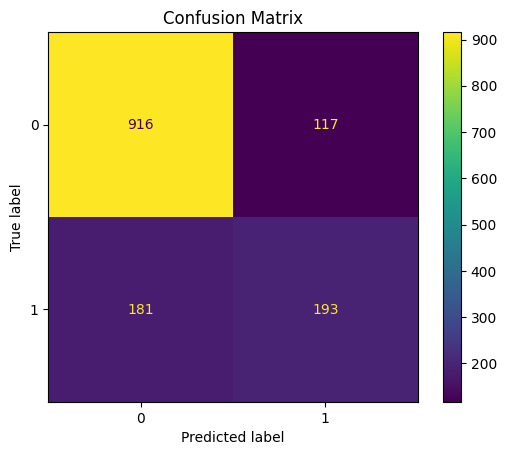

In [4]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [6]:
# ==========================================
# Test Customer Churn Model (Fixed)
# ==========================================

import pandas as pd
import joblib

# Load model
model = joblib.load("churn_pipeline.pkl")

print("Model loaded successfully!")

# FULL sample input (all columns)
sample_data = pd.DataFrame({
    "gender": ["Male"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [12],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["DSL"],
    "OnlineSecurity": ["Yes"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["Yes"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [70.35],
    "TotalCharges": [844.2]
})

# Predict
prediction = model.predict(sample_data)[0]

# Output label
result = "Churn" if prediction == 1 else "No Churn"

print("\nPrediction:", result)

Model loaded successfully!

Prediction: No Churn


In [ ]:
# note
The dataset is slightly imbalanced, which affects the F1-score.
Logistic Regression performed slightly better than Random Forest.
The pipeline ensures reusable and production-ready workflow.